# [미션 시나리오]

- L기관(국방·응급의료 AI 연구팀) : 재난·전장 현장의 응급처치를 지원하는 **전술적 전투 부상자 처치(TCCC) AI 솔루션 전문 조직**
    - 헬멧 캠으로 수집한 1인칭(egocentric) 영상을 분석해
    - 현장 술기를 자동으로 인식·보조하는 영상 AI 기술을 개발하는 조직
    - 데이터 체계
      - THOMPSON 프로젝트(Trauma TeleHelper for Operational Medical Procedure Support and Offline Network)의 일환
      - 훈련생이 머리에 착용한 카메라로 촬영한 술기 시뮬레이션 영상에서 프레임을 추출하고,
      - 각 프레임에 등장하는 의료 도구마다 Bounding Box와 클래스를 주석해 수집.
          1. 이미지 폴더·라벨 폴더·클래스 정의(data.yaml)를 클립(clip)·프레임 단위로 구조화하면,
          2. 어떤 시나리오에서 어떤 도구가 언제 어떤 위치·크기로 등장하는지를 한눈에 조회·분석할 수 있는 방식으로 운용
<br>

- 후송 전 골든타임 내 정확한 술기 수행이 생존율과 직결되지만,
    - 현장은 통신이 제한되고(Offline Network)
    - 처치자가 단독으로 다수의 도구를 신속히 다뤄야 하는 고압 상황이어서,
    - 도구 인식·술기 절차를 자동으로 보조하는 역량이 절실
      - 그러나 헬멧 캠 1인칭 영상은 시점이 급격히 흔들리고
      - 도구가 손·신체에 가려지며,
      - 화면 속 도구가 매우 작게 나타나는 경우가 많아 객체 탐지가 어렵다.
      - 또한 클립(촬영 시나리오)별로 등장하는 도구 종류와 빈도가 크게 달라 클래스·클립 간 데이터 불균형이 심하고,
      - 박스가 없는 프레임과 극소형 박스가 섞여 있어 그대로는 신뢰성 있는 탐지·분류 모델을 구축하기 어려운 상황

- 기회 요인
    - 14개 클립·약 15,881장의 프레임에 도구별 Bounding Box가 정밀 주석되어 있어, 정규화 좌표를 픽셀 좌표로 복원해 박스 크기·분포와 클래스·클립별 불균형을 규명하고, 도구 이미지 분류 모형과 객체 탐지 모형을 함께 구축하는 데이터 기반 술기 보조 체계를 만들 수 있다.
    - 다만 이를 위해서는
      1. 이미지·라벨·클래스 정의를 박스 단위로 평탄화하고 split·clip·frame 등으로 구조화해 분석 가능한 데이터로 정제해야 하며,
      2. 클래스·클립별 박스 분포와 소형 객체 비율을 시각화해 탐지 난이도와 데이터 편향을 규명해야 하고,
      3. 검출 박스를 잘라낸 도구 분류 모형(ResNet50 전이학습)과 YOLOv8 객체 탐지 모형을 구성하고 클래스별 AP의 신뢰성을 검증해 탐지 체계의 신뢰도를 끌어올려야 한다.

 *L기관은 데이터 분석팀을 구성하여,*  
 구조화된 프레임·박스·클래스 데이터를 활용/분석하여,이학습 기반 도구 분류 모형과 YOLOv8 기반 객체 탐지 모형을 구성·검증해 전장·재난 현장 술기 보조와 도구 인식의 신뢰도를 높이고자 한다.
 - **어떤 도구가 어떤 시나리오에서 얼마나 등장하는지,**
 - **소형 객체와 데이터 불균형이 탐지에 어떤 문제를 일으키는지,**
 - **도구 분류와 객체 탐지 모형의 성능은 어떻게 다르고 어디까지 신뢰할 수 있는지**


# [데이터, 라이브러리 불러오기]

In [1]:
import zipfile
import os

zip_path = '/content/05_TCCC_Object_640.zip'
extract_dir = '/content/05_TCCC_Object_640'

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_path}' extracted to '{extract_dir}'")

print(f"Contents of '{extract_dir}':")
for item in os.listdir(extract_dir):
    print(f"- {item}")

'/content/05_TCCC_Object_640.zip' extracted to '/content/05_TCCC_Object_640'
Contents of '/content/05_TCCC_Object_640':
- labels
- stats.json
- data.yaml
- images


In [39]:
import pandas as pd
import numpy as np, torch, time
import os, glob
import yaml
from pathlib import Path

# [미션풀이]

- 해당 데이터는 THOMPSON의 일부로, 재난 및 전장 현장에서 벌어지는 사상자에 대한 후송 전 처치 상황을 헬멧 캠으로 수집한 데이터이다.
(*Trauma TeleHelper for Operational Medical Procedure Support and Offline Network)
- 훈련생이 머리에 착용한 카메라로 촬영한 1인칭(egocentric) 영상 14개 클립에서 프레임을 뽑아낸 자료. (모든 이미지 프레임은 640 x 360)
- 마네킹을 대상으로 한 술기 시뮬레이션이며, 화면에 등장하는 **의료 도구마다 Bounding Box** 가 주석되어 있음.


# [미션 시작]

## **[미션 1]** images 폴더 / labels 폴더와 data.yaml 데이터를 가져와 아래와 같이 데이터 프레임을 구성하시오.

    - 이미지 내 Box 하나가 하나의 Row가 되도록 평탄화
    (1장에 이미지에 Box가 5개 있으면 5개 Row가 생성)
    - 각 폴더에 train / val 구분은 split 항목으로 구분
    - 각 파일 명은 stem 항목으로 구분
    - 파일명에서 앞 6글자는 clip 항목(clip ID)으로 구분 (하나의 비디오에서 나온 이미지)
    - 파일명에서 clip ID 뒤는 frame으로 구분
    - data.yaml 파일에 클래스 이름은 cls로 구분
    - data.yaml 파일에 각 클래스의 cx, cy, w, h 값을 각각의 항목으로 구분
    - Box가 없는 이미지의 경우, cls에 -1 값으로 구분
    - 최종 처리 결과는 46,660개 Row / 10개 Columns
        - 이미지 파일(폴더)에서 나오는 항목 → split / stem / clip / frame / img_path
        - data.yaml 에서 나오는 항목 → cls / cx / cy / w / h
            - 전체 행 수            : 46660
            - 전체 이미지 수        : 15881
            - 클립 수               : 14

1. 라벨 파일 하나를 열어 박스마다 dict 하나를 만들기
2. 전부 리스트에 쌓기
3. 마지막에 한 번에 DataFrame으로 변환

In [7]:
# 05_TCCC_Object_640  →  "박스 1개 = 행 1개" 형태의 DataFrame 만들기

ROOT = Path("/content/05_TCCC_Object_640")

def parse_yolo_label(img_path):
    # 이미지 경로로부터 식별 정보 추출
    stem     = os.path.basename(img_path).rsplit('.', 1)[0]   # 'P01_01_123'
    split    = os.path.basename(os.path.dirname(img_path))    # 상위 폴더명 = 'train'/'val'
    clip     = stem[:6]                                       # 앞 6글자 = 클립 ID
    frame    = stem[6:].lstrip('_')                           # 클립 ID 뒤 = 프레임 번호
    frame    = int(frame) if frame.isdigit() else frame

    # YOLO 규칙: images/train/xxx.jpg ↔ labels/train/xxx.txt
    lbl_path = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

    # 이 이미지의 모든 행에 공통으로 들어갈 5개 항목
    base = {'split': split, 'stem': stem, 'clip': clip,
            'frame': frame, 'img_path': img_path}

    row_list = []                        # 각각의 Box 정보가 하나씩 추가
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:               # 한 줄 = Box 한 개
                parts = line.split()
                if len(parts) < 5:       # 빈 줄 / 깨진 줄 skip
                    continue
                cls, cx, cy, w, h = parts[:5]
                row_list.append({**base,
                                 'cls': int(float(cls)),
                                 'cx' : float(cx), 'cy': float(cy),
                                 'w'  : float(w),  'h' : float(h)})

    # Box가 없는 이미지의 경우, cls에 -1 값으로 구분
    if not row_list:
        row_list.append({**base, 'cls': -1,
                         'cx': None, 'cy': None, 'w': None, 'h': None})
    return row_list


In [8]:
# '이미지' 기준으로 목록을 만들기
img_list = sorted(glob.glob(os.path.join(ROOT, 'images', '*', '*.jpg')))

box_list = []
for img_path in img_list:
    box_list.extend(parse_yolo_label(img_path))

df_box = pd.DataFrame(box_list)
print(df_box.shape)
df_box.head(5)

(46660, 10)


,split,stem,clip,frame,img_path,cls,cx,cy,w,h
0,train,P01_01_0,P01_01,0,/content/05_TCCC_Object_640/images/train/P01_0...,12,0.172917,0.549537,0.081250,0.260185
1,train,P01_01_0,P01_01,0,/content/05_TCCC_Object_640/images/train/P01_0...,13,0.163021,0.653704,0.042708,0.088889
2,train,P01_01_0,P01_01,0,/content/05_TCCC_Object_640/images/train/P01_0...,11,0.239323,0.628704,0.050521,0.261111
3,train,P01_01_0,P01_01,0,/content/05_TCCC_Object_640/images/train/P01_0...,14,0.301823,0.637500,0.040104,0.243519
4,train,P01_01_0,P01_01,0,/content/05_TCCC_Object_640/images/train/P01_0...,10,0.358073,0.618519,0.032813,0.229630


In [13]:
print(f"전체 행 수             : {len(df_box)}")
print(f"전체 이미지 수          : {df_box['stem'].nunique()}")
print(f"클립 수                : {df_box['clip'].nunique()}")
print(f"컬럼 수                : {df_box.shape[1]}")
print(f"Box 없는 이미지(cls=-1) : {(df_box['cls'] == -1).sum()}")
print(f"실제 Box 수            : {(df_box['cls'] != -1).sum()}")

print("\n[split별 이미지 수]")
print(df_box.groupby("split")["stem"].nunique())

print("\n[split별 Box 수]")
print(df_box[df_box["cls"] != -1].groupby("split").size())

print("\n[컬럼 목록]", list(df_box.columns))
print("\n[클립별 이미지 수]")
print(df_box.groupby("clip")["stem"].nunique())

전체 행 수             : 46660
전체 이미지 수          : 15881
클립 수                : 14
컬럼 수                : 10
Box 없는 이미지(cls=-1) : 1588
실제 Box 수            : 45072

[split별 이미지 수]
split
train    12705
val       3176
Name: stem, dtype: int64

[split별 Box 수]
split
train    35758
val       9314
dtype: int64

[컬럼 목록] ['split', 'stem', 'clip', 'frame', 'img_path', 'cls', 'cx', 'cy', 'w', 'h']

[클립별 이미지 수]
clip
P01_01    2082
P01_02    1631
P02_02    1131
P02_03    1468
P02_05    1402
P02_06    1908
P02_07     284
P04_01    1407
P04_03     510
P04_05    1243
P05_01     736
P05_02     813
P05_03     676
P05_05     590
Name: stem, dtype: int64


## **[미션 2]** 앞서 처리된 데이터 프레임을 호출하고, 박스가 있는 형태의 행만 추출한 뒤 (클래스가 -1인 값 제외)
- 클래스 별 박스 수와 클립(clip, 촬영 시나리오 별)별 클래스 수,
- 박스수를 확인

### 클래스 별 박스 수 : 막대 그래프를 이용해 시각화

In [14]:
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')  # 런타임 재시작 없이 등록
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

In [15]:
import seaborn as sns

# 박스 있는 행만 추출
df_obj = df_box[df_box["cls"] != -1].copy()  # cls == -1 은 '박스가 없는 이미지'므로 제외

print("박스 있는 행 :", len(df_obj))
print("제외된 행    :", len(df_box) - len(df_obj))

박스 있는 행 : 45072
제외된 행    : 1588


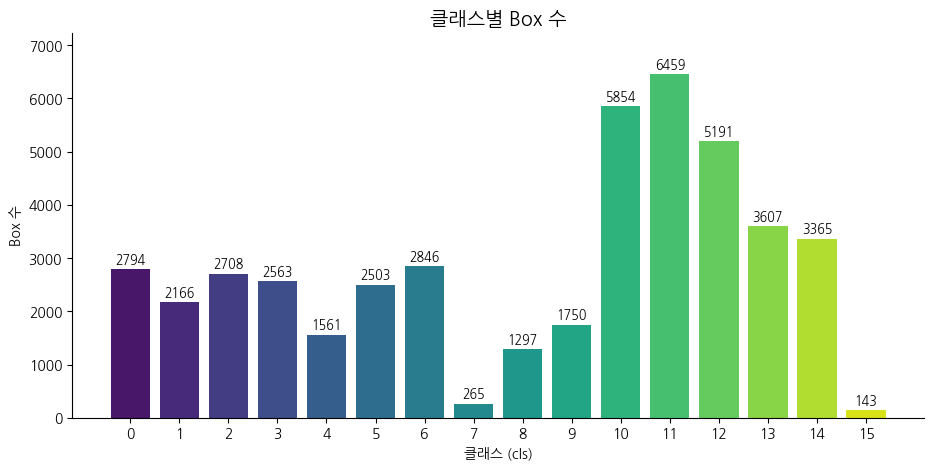

In [29]:
# 클래스별 박스 수 (막대그래프)
cls_cnt = df_obj["cls"].value_counts().sort_index() # 클래스 번호순으로 보려면 sort_index()
# print(cls_cnt)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(cls_cnt.index.astype(str),          # x축을 문자열로 → 0~15가 빠짐없이 표시됨
              cls_cnt.values,
              color=sns.color_palette("viridis", len(cls_cnt)))

ax.bar_label(bars, fmt="%d", fontsize=9, padding=2)   # 막대 위에 숫자 표기
ax.set_title("클래스별 Box 수", fontsize=14)
ax.set_xlabel("클래스 (cls)")
ax.set_ylabel("Box 수")
ax.margins(y=0.12)        # 맨 위 숫자가 잘리지 않도록 여백 확보
sns.despine(ax=ax)        # 위/오른쪽 테두리 제거
plt.show()

### 클립(clip, 촬영 시나리오 별)별 클래스 수와 박스 수 - 히트맵

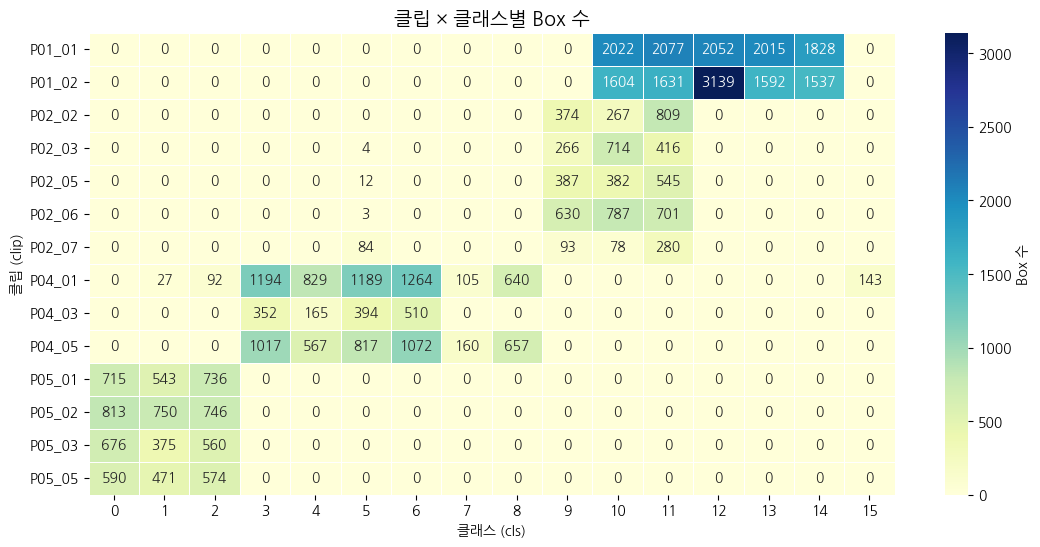

In [19]:
# 클립 × 클래스 (히트맵)
# crosstab = 행(clip) × 열(cls) 교차표
pivot = pd.crosstab(df_obj["clip"], df_obj["cls"])
# print(pivot)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot,
            annot=True, fmt="d",        # 칸 안에 실제 개수 표시 (d = 정수)
            cmap="YlGnBu",
            linewidths=.5, linecolor="white",
            cbar_kws={"label": "Box 수"}, ax=ax)

ax.set_title("클립 × 클래스별 Box 수", fontsize=14)
ax.set_xlabel("클래스 (cls)")
ax.set_ylabel("클립 (clip)")
plt.show()

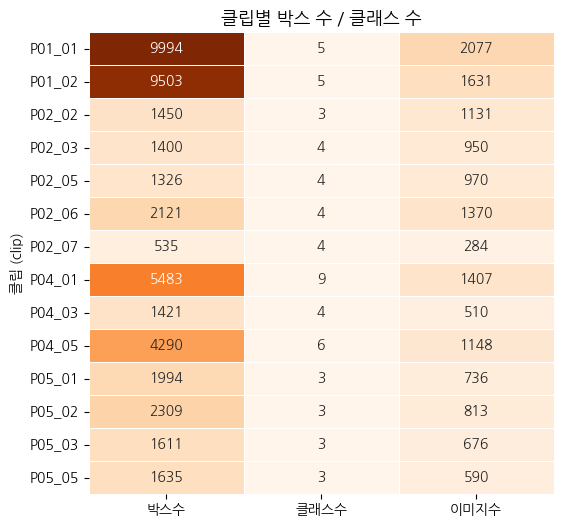

In [20]:
# 클립별 박스 수 / 클래스 수 요약 (히트맵)
summary = (df_obj.groupby("clip")
           .agg(박스수   = ("cls", "size"),      # 행 개수 = 박스 개수
                클래스수 = ("cls", "nunique"),   # 고유 클래스 개수
                이미지수 = ("stem", "nunique")))
# print(summary)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(summary, annot=True, fmt="d", cmap="Oranges",
            linewidths=.5, linecolor="white", cbar=False, ax=ax)
ax.set_title("클립별 박스 수 / 클래스 수", fontsize=13)
ax.set_ylabel("클립 (clip)")
ax.set_xlabel("")
plt.show()

### 시각화 결과
- 해당 데이터의 객체 인식에서 발생할 수 있는 문제

In [22]:
import pandas as pd, numpy as np
from PIL import Image

# 박스 단위 DataFrame → 이미지 단위로 축소
img = (df_box.drop_duplicates("stem")[["split", "stem", "clip", "frame", "img_path"]]
             .sort_values(["clip", "frame"])
             .reset_index(drop=True))

print("이미지 장수 :", len(img))
print("클립 개수   :", img["clip"].nunique())
print("클립 목록   :", sorted(img["clip"].unique()))
print()

# 클립별 영상 길이 역산
per_clip = img.groupby("clip").agg(
    이미지수  = ("stem", "size"),
    최소frame = ("frame", "min"),
    최대frame = ("frame", "max"),
)
per_clip["원본프레임수"]      = per_clip["최대frame"] - per_clip["최소frame"] + 1
per_clip["영상길이_초_30fps"] = (per_clip["원본프레임수"] / 30).round(1)
display(per_clip)
print("총 영상 길이(30fps 가정) : 약 %.1f분"
      % (per_clip["영상길이_초_30fps"].sum() / 60))

img["gap"] = img.groupby("clip")["frame"].diff()
print("\n[프레임 추출 간격]")
print(img["gap"].value_counts().head())

# 인접 프레임이 실제로 얼마나 비슷한가
rng = np.random.default_rng(0)

def load(path):   # 흑백 + 축소 (비교만 할 거라 원본 해상도 불필요)
    return np.asarray(Image.open(path).convert("L").resize((160, 160)), dtype=np.float32)

adj = []                                        # 바로 옆 프레임끼리
for i in rng.choice(len(img) - 1, 300, replace=False):
    a, b = img.iloc[i], img.iloc[i + 1]
    if a["clip"] != b["clip"]:                  # 클립 경계는 제외
        continue
    adj.append(np.abs(load(a["img_path"]) - load(b["img_path"])).mean())
    if len(adj) >= 100:
        break

clips, rnd = img["clip"].unique(), []           # 같은 클립 내 무작위 두 장 (비교 기준)
for _ in range(100):
    c = rng.choice(clips)
    s = img[img["clip"] == c].sample(2)
    rnd.append(np.abs(load(s.iloc[0]["img_path"]) - load(s.iloc[1]["img_path"])).mean())

print("\n인접 프레임 픽셀 평균차이 : %.2f (0~255)" % np.mean(adj))
print("같은 클립 무작위 쌍 차이  : %.2f" % np.mean(rnd))
print("→ 인접 프레임 차이는 무작위 쌍의 %.0f%% 수준"
      % (np.mean(adj) / np.mean(rnd) * 100))

이미지 장수 : 15881
클립 개수   : 14
클립 목록   : ['P01_01', 'P01_02', 'P02_02', 'P02_03', 'P02_05', 'P02_06', 'P02_07', 'P04_01', 'P04_03', 'P04_05', 'P05_01', 'P05_02', 'P05_03', 'P05_05']



,이미지수,최소frame,최대frame,원본프레임수,영상길이_초_30fps
clip,,,,,
P01_01,2082,0,4162,4163,138.8
P01_02,1631,0,3260,3261,108.7
P02_02,1131,142,3190,3049,101.6
P02_03,1468,0,2938,2939,98.0
P02_05,1402,0,2802,2803,93.4
P02_06,1908,0,3847,3848,128.3
P02_07,284,168,972,805,26.8
P04_01,1407,0,2812,2813,93.8
P04_03,510,0,1018,1019,34.0


총 영상 길이(30fps 가정) : 약 18.3분

[프레임 추출 간격]
gap
2.0      15845
6.0          3
3.0          2
74.0         1
117.0        1
Name: count, dtype: int64

인접 프레임 픽셀 평균차이 : 5.34 (0~255)
같은 클립 무작위 쌍 차이  : 40.11
→ 인접 프레임 차이는 무작위 쌍의 13% 수준


 **✏️ 시각화 결과를 미뤄 볼 때, 해당 데이터의 객체 인식에서 발생할 수 있는 문제에 대해 간단히 서술하시오.**

  1. 심한 클래스 불균형
      - 막대 그래프에서 cls 11(6,459개) vs cls 15(143), 7(265)
      - 드문 술기일수록 놓치면 안되는 경우일 수 있어, 빈도와 중요도가 반비례할 위험이 있음
  2. 클립과 클래스가 결합되어 있음
      - 특정 클래스는 특정 촬영 장면에서만 등장
      - 장면 감지기가 되어 학습에 없던 새로운 촬영 환경에서는 성능이 급격히 무너질 가능성이 높다.
  3. 프레임 중복과 클립 단위 누수로 인한 성능 과대평가
      - 이미지 15,881장은 많아 보이지만 실제로는 14개 영상에서 뽑은 프레임,
      - 프레임 간격 중앙값이 2에 불과해 인접 이미지들이 사실상 같은 장면임
      - 독립적인 샘플 수는 15,881이 아니라 14에 가깝다.

      - 14개 클립이 모두 train과 val 양쪽에 들어가 있다
          - 클립별로 앞 약 80% 프레임이 train,
          - 뒤 20%가 val로 시간순 분할되어 있음,
          - val에는 train에서 본 적 없는 장면이 하나도 없음. 검증 점수가 실제 일반화 성능보다 높게 나올 수밖에 없음.


## **[미션 3]** 정규화 좌표(0 ~ 1)를 픽셀 코너 좌표로 복원하고,

- 박스의 크기 분포
- 이미지 당 박스 수


In [23]:
import collections

sizes = collections.Counter()
for p in df_box["img_path"].unique():
    sizes[Image.open(p).size] += 1
print(sizes)

Counter({(640, 360): 15881})


In [24]:
# 정규화 좌표 → 픽셀 코너 좌표

IMG_W, IMG_H = 640, 360

df_obj = df_box[df_box["cls"] != -1].copy()   # 박스 있는 행만

# YOLO 형식 : cx, cy, w, h 를 0~1로 정규화한 값.
df_obj["x1"] = (df_obj["cx"] - df_obj["w"] / 2) * IMG_W   # 좌상단 x
df_obj["y1"] = (df_obj["cy"] - df_obj["h"] / 2) * IMG_H   # 좌상단 y
df_obj["x2"] = (df_obj["cx"] + df_obj["w"] / 2) * IMG_W   # 우하단 x
df_obj["y2"] = (df_obj["cy"] + df_obj["h"] / 2) * IMG_H   # 우하단 y

# 크기 관련 파생 변수
df_obj["bw"]   = df_obj["w"] * IMG_W          # 박스 너비 (px)
df_obj["bh"]   = df_obj["h"] * IMG_H          # 박스 높이 (px)
df_obj["area"] = df_obj["bw"] * df_obj["bh"]  # 면적 (px²)
df_obj["ar"]   = df_obj["bw"] / df_obj["bh"]  # 종횡비 (1보다 작으면 세로로 긴 박스)

display(df_obj[["stem","cls","cx","cy","w","h","x1","y1","x2","y2"]].head(3).round(1))

# 좌표가 이미지 밖으로 나가지 않는지 검사
out = ((df_obj.x1 < 0) | (df_obj.y1 < 0) |
       (df_obj.x2 > IMG_W) | (df_obj.y2 > IMG_H)).sum()
print("경계를 벗어난 박스 :", out)

,stem,cls,cx,cy,w,h,x1,y1,x2,y2
0,P01_01_0,12,0.2,0.5,0.1,0.3,84.7,151.0,136.7,244.7
1,P01_01_0,13,0.2,0.7,0.0,0.1,90.7,219.3,118.0,251.3
2,P01_01_0,11,0.2,0.6,0.1,0.3,137.0,179.3,169.3,273.3


경계를 벗어난 박스 : 274


### 박스 크기 분포

In [26]:
# 박스 크기 분포
display(df_obj[["bw","bh","area","ar"]]   # bw(박스 너비 px) / bh(박스 높이 px) / area(면적 px²) / ar(종횡비)
        .describe(percentiles=[.05,.25,.5,.75,.95]).round(1))

# COCO 표준 기준으로 소/중/대 분류
bins = [0, 32**2, 96**2, np.inf]
df_obj["size_cat"] = pd.cut(df_obj["area"], bins=bins,
                            labels=["small(<32²)", "medium(32²~96²)", "large(>96²)"])
print((df_obj["size_cat"].value_counts(normalize=True).sort_index() * 100).round(1))

,bw,bh,area,ar
count,45072.0,45072.0,45072.0,45072.0
mean,46.8,75.7,4003.1,0.8
std,35.0,40.3,5611.0,0.7
min,2.3,3.0,13.2,0.1
5%,16.7,23.7,583.8,0.2
25%,27.3,46.7,1533.9,0.3
50%,38.3,70.3,2551.4,0.6
75%,52.0,97.3,4231.0,1.0
95%,108.3,139.7,12726.7,2.0
max,355.7,357.7,76454.4,8.5


size_cat
small(<32²)        12.1
medium(32²~96²)    80.6
large(>96²)         7.2
Name: proportion, dtype: float64


### 이미지 박스 수

In [27]:
# 이미지당 박스 수
cnt = df_obj.groupby("stem").size()
cnt_all = cnt.reindex(df_box["stem"].unique(), fill_value=0)  # reindex로 박스 0개 이미지(1,588장)까지 포함

print(cnt_all.describe().round(2))
print(cnt_all.value_counts().sort_index())

count    15881.00
mean         2.84
std          1.89
min          0.00
25%          1.00
50%          3.00
75%          5.00
max          6.00
dtype: float64
0    1588
1    3707
2    1771
3    3296
4    1233
5    2713
6    1573
Name: count, dtype: int64


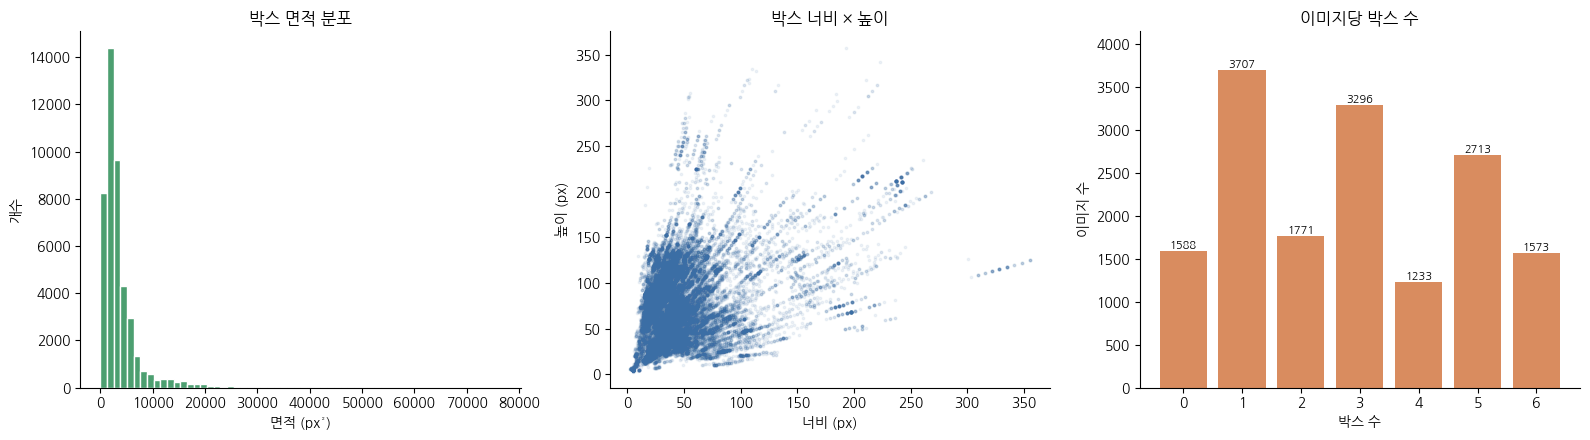

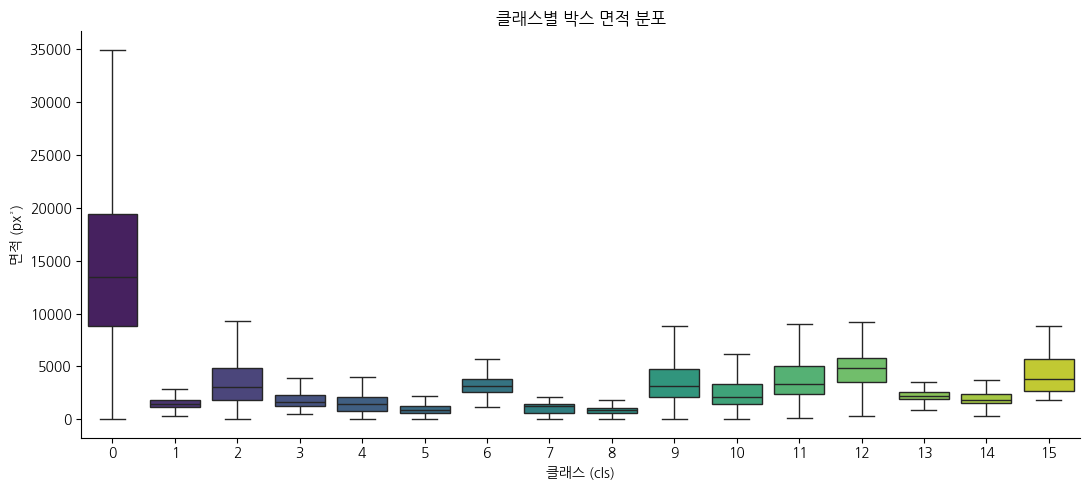

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(df_obj["area"], bins=60, color="#4C9F70", edgecolor="white")
axes[0].set_title("박스 면적 분포"); axes[0].set_xlabel("면적 (px²)"); axes[0].set_ylabel("개수")

axes[1].scatter(df_obj["bw"], df_obj["bh"], s=3, alpha=.08, color="#3B6EA5")
axes[1].set_title("박스 너비 × 높이"); axes[1].set_xlabel("너비 (px)"); axes[1].set_ylabel("높이 (px)")

vc = cnt_all.value_counts().sort_index()
b = axes[2].bar(vc.index.astype(str), vc.values, color="#D98C5F")
axes[2].bar_label(b, fmt="%d", fontsize=8)
axes[2].set_title("이미지당 박스 수"); axes[2].set_xlabel("박스 수"); axes[2].set_ylabel("이미지 수")
axes[2].margins(y=.12)

for a in axes:
    sns.despine(ax=a)
plt.tight_layout(); plt.show()

# 클래스별 면적 분포
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_obj, x="cls", y="area", hue="cls", legend=False,
            showfliers=False, palette=sns.color_palette("viridis", 16), ax=ax)
ax.set_title("클래스별 박스 면적 분포"); ax.set_xlabel("클래스 (cls)"); ax.set_ylabel("면적 (px²)")
sns.despine(ax=ax); plt.tight_layout(); plt.show()

**차트 1. 박스 면적 분포**

- 왼쪽 끝에 산처럼 몰려 있고 오른쪽으로 길게 꼬리가 늘어진 모양
- x축은 박스 면적(px²), y축은 그 크기의 박스가 몇 개인지
- 대부분의 박스가 작고(2,500px² 근처), 아주 큰 박스가 드물게 섞여 있음.
- 면적 10,000px² 넘는 박스는 6.6%뿐이고, 가로축이 80,000까지 늘어난 건 극소수 때문
- 평균 면적은 4,003px²인데 중앙값은 2,551px²입니다. 큰 박스 몇 개가 평균을 끌어올린 것, 이 데이터를 요약할 땐 중앙값을 써야 함.

**차트 2. 박스 너비 × 높이**
- 왼쪽 아래에 뭉친 덩어리 + 부채살처럼 뻗어나간 여러 줄기
- 점 하나가 박스 하나. x = w / y = h.
- 점들이 대각선(너비=높이) 위쪽에 주로 있음(높이 > 너비). 즉 세로로 긴 박스.

**차트 3. 이미지당 박스 수**
- 1·3·5가 높고 0·2·4·6이 낮은 톱니 모양
- 장면당 박스가 6개를 넘지 않음다. 한 화면에 도구가 최대 6개만 나온다는 뜻.
- 0개가 1,588장 - 도구가 안 보이는 장면(카메라가 다른 곳을 볼 때)

**차트 4. 클래스별 박스 면적 분포** (박스플롯)
- 상자가 두꺼우면 크기가 제각각, 얇으면 크기가 일정하다는 뜻
- 맨 왼쪽 cls 0만 압도적으로 크고 높이 솟아 있고, 나머지는 바닥에 낮게 깔려 있음.
- cls 0이 유독 크고 두꺼움. 개별 도구가 아닌 신체 부위나 처치 부위 전체를 잡는 것으로 보임.

## **[미션 4]** 픽셀 코너 좌표로 복원된 Box 데이터 중

- 32x32 픽셀(1,024)미만의 데이터 비율


In [32]:
IMG_W, IMG_H = 640, 360

df_obj = df_box[df_box["cls"] != -1].copy()

# 정규화 → 픽셀
df_obj["bw"]   = df_obj["w"] * IMG_W
df_obj["bh"]   = df_obj["h"] * IMG_H
df_obj["area"] = df_obj["bw"] * df_obj["bh"]

# 32×32 = 1024 px² 미만 판별
df_obj["is_small"] = df_obj["area"] < 32 * 32

n     = len(df_obj)
small = df_obj["is_small"].sum()

print(f"전체 박스 수         : {n:,}")
print(f"small(<1,024px²)  : {small:,}")
print(f"32x32 픽셀미만 비율   : {small / n * 100:.2f}%")

전체 박스 수         : 45,072
small(<1,024px²)  : 5,460
32x32 픽셀미만 비율   : 12.11%


## **[미션 5]** 아래 6장의 이미지에 대해, 아래와 같이 이미지 내 박스를 시각화 하시오.
    - 'P01_01_0', 'P02_02_1085', 'P04_01_0', 'P05_01_0', 'P01_02_0', 'P02_06_1724'

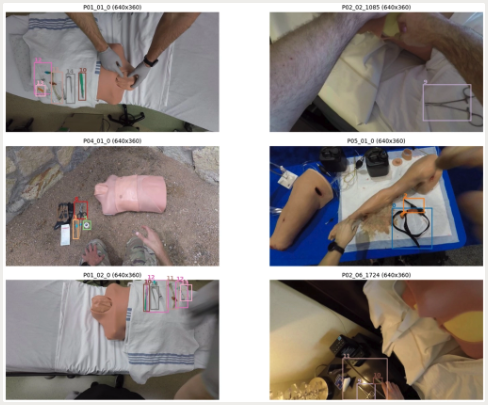

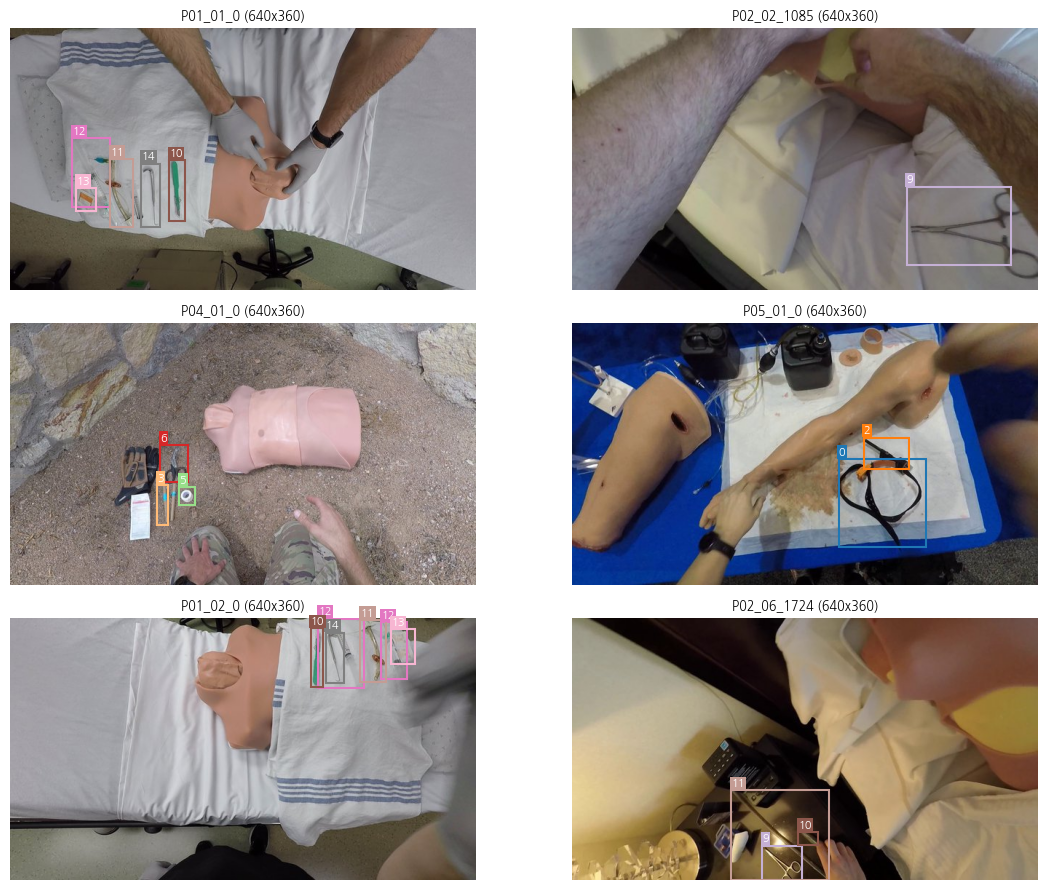

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mp

IMG_W, IMG_H = 640, 360
CLS_COLORS = plt.get_cmap("tab20")(np.linspace(0, 1, 20))   # 클래스별 고정 색상

sample_stems = ['P01_01_0', 'P02_02_1085', 'P04_01_0',
                'P05_01_0', 'P01_02_0', 'P02_06_1724']

fig, axes = plt.subplots(3, 2, figsize=(12, 9))             # 3행 × 2열

for ax, stem in zip(axes.ravel(), sample_stems):
    rows = df_box[df_box["stem"] == stem]
    img  = Image.open(rows.iloc[0]["img_path"])
    ax.imshow(img)

    for _, b in rows[rows["cls"] != -1].iterrows():         # cls=-1(박스 없음) 제외
        # 정규화(중심,크기) → 픽셀(좌상단,크기)
        x1 = (b["cx"] - b["w"] / 2) * IMG_W
        y1 = (b["cy"] - b["h"] / 2) * IMG_H
        bw, bh = b["w"] * IMG_W, b["h"] * IMG_H

        color = CLS_COLORS[int(b["cls"]) % 20]
        ax.add_patch(mp.Rectangle((x1, y1), bw, bh,
                                  fill=False, edgecolor=color, lw=1.5))
        ax.text(x1, y1 - 2, str(int(b["cls"])), color="white", fontsize=8, va="bottom",   # 라벨을 클래스 이름으로
                bbox=dict(facecolor=color, edgecolor="none", pad=1))                      # 라벨에 배경 넣기

    ax.set_title(f"{stem} ({img.width}x{img.height})", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

| stem | 박스 | 클래스 | 장면 |
| -- | -- | -- | -- |
| P01_01_0 | 5 | 10, 11, 12, 13, 14 | 실내 침대, 도구 5종 나열 |
| P02_02_1085 | 1 | 9 | 침대 위 지혈겸자 1개 |
| P04_01_0 | 3 | 3, 5, 6 | 야외 모래밭, 마네킹 옆 도구 |
| P05_01_0 | 2 | 0, 2 | 파란 매트, 팔 처치 |
| P01_02_0 | 6 | 10, 11, 12, 12, 13, 14 | 도구 6개 (cls 12가 2개) |
| P02_06_1724 | 3 | 9, 10, 11 | 어두운 실내 |

## **[미션 6]** 검출 라벨의 박스를 잘라내 **도구 이미지 분류 데이터셋**을 구성하고,

- ResNet50 전이학습으로 16종 도구를 분류한 뒤 혼동행렬로 평가


  - 각 이미지에서 검출 라벨 박스를 잘라내는 함수를 구성하시오.
  - 클래스별 이미지 수를 제한하여 학습 시간을 조절하시오. (최대 300장)
  - 검증 데이터를 활용해 평가를 수행하고, 혼동행렬을 Heatmap 시각화 하시오.
  - 학습한 모델을 저장하시오.

In [37]:
# 박스 크롭 추출

IMG_W, IMG_H = 640, 360
PAD = 0.10                      # 박스 주변 10% 여유(맥락) 포함
OUT = Path("crops")

df_obj = df_box[df_box["cls"] != -1].copy()

# 정규화 → 픽셀 코너 좌표
df_obj["x1"] = (df_obj.cx - df_obj.w/2) * IMG_W
df_obj["y1"] = (df_obj.cy - df_obj.h/2) * IMG_H
df_obj["x2"] = (df_obj.cx + df_obj.w/2) * IMG_W
df_obj["y2"] = (df_obj.cy + df_obj.h/2) * IMG_H
df_obj["area"] = (df_obj.x2 - df_obj.x1) * (df_obj.y2 - df_obj.y1)

# 너무 작은 박스는 확대해도 형체를 알 수 없어 학습 노이즈가 될 수 있음 - 제외
print("면적 <100px² 제외 :", (df_obj.area < 100).sum())
df_obj = df_obj[df_obj.area >= 100].reset_index(drop=True)

# 여유(PAD) 적용 후 이미지 경계로 자르기
bw, bh = df_obj.x2 - df_obj.x1, df_obj.y2 - df_obj.y1
df_obj["cx1"] = (df_obj.x1 - bw*PAD).clip(0, IMG_W)
df_obj["cy1"] = (df_obj.y1 - bh*PAD).clip(0, IMG_H)
df_obj["cx2"] = (df_obj.x2 + bw*PAD).clip(0, IMG_W)
df_obj["cy2"] = (df_obj.y2 + bh*PAD).clip(0, IMG_H)

for sp in ["train", "val"]:
    for c in range(16):
        (OUT/sp/f"{c:02d}").mkdir(parents=True, exist_ok=True)

rows = []
# groupby로 이미지당 한 번만 열기
for img_path, g in df_obj.groupby("img_path", sort=False):
    im = Image.open(img_path).convert("RGB")
    for i, b in enumerate(g.itertuples()):
        dst = OUT/b.split/f"{int(b.cls):02d}"/f"{b.stem}_{i}.jpg"
        im.crop((b.cx1, b.cy1, b.cx2, b.cy2)).save(dst, quality=92)
        rows.append({"crop_path": str(dst), "split": b.split,
                     "cls": int(b.cls), "clip": b.clip, "stem": b.stem})

crops = pd.DataFrame(rows)
crops.to_csv("crops_index.csv", index=False)
print(f"크롭 완료 {len(crops)}개")

면적 <100px² 제외 : 327
크롭 완료 44745개


In [38]:
# 클래스별 최대 300장 제한

CAP_TRAIN, CAP_VAL = 300, 100

def cap_per_class(df, n):   # 클래스별 최대 n장(프레임 순서를 따라 '균등 간격'으로 추출)
    out = []
    for cls, g in df.groupby("cls"):
        g = g.sort_values(["clip", "stem"])
        if len(g) > n:
            g = g.iloc[np.linspace(0, len(g)-1, n).astype(int)] # np.linspace() '균등 간격'으로 추출
        out.append(g)
    return pd.concat(out).reset_index(drop=True)

tr = cap_per_class(crops[crops.split == "train"], CAP_TRAIN)
va = cap_per_class(crops[crops.split == "val"],   CAP_VAL)

print("train:", len(tr), "| val:", len(va))

train: 4545 | val: 1450


In [ ]:
# ResNet50 전이 학습
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

SEED = 42; torch.manual_seed(SEED); np.random.seed(SEED)   # 재현성 고정
DEV = "cuda" if torch.cuda.is_available() else "cpu"       # Colab GPU 런타임 필수
print("device:", DEV)

IMG_SIZE, BATCH, EPOCHS, LR = 224, 64, 6, 3e-4
MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]       # ImageNet 사전학습 통계값

# 학습용: 증강 포함 / 검증용: 증강 없이 순수 평가
tf_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),          # 도구는 좌우 반전해도 같은 도구
    transforms.ColorJitter(0.2, 0.2, 0.2),      # 조명 차이(실내/야외)에 강건하게
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
tf_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

class CropDS(Dataset):
    """crops_index.csv 한 줄 = 크롭 이미지 1장"""
    def __init__(s, df, tf): s.df = df.reset_index(drop=True); s.tf = tf
    def __len__(s): return len(s.df)
    def __getitem__(s, i):
        r = s.df.iloc[i]
        return s.tf(Image.open(r.crop_path).convert("RGB")), int(r.cls)

dl_tr = DataLoader(CropDS(tr, tf_train), batch_size=BATCH, shuffle=True,  num_workers=2)
dl_va = DataLoader(CropDS(va, tf_val),   batch_size=BATCH, shuffle=False, num_workers=2)

# ── 모델: ImageNet 사전학습 ResNet50 → 마지막 층만 16종으로 교체 ──
m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for p in m.parameters():
    p.requires_grad = False                     # 1단계에서는 백본 전체 동결
m.fc = nn.Linear(m.fc.in_features, 16)          # 1000종 → 16종
m = m.to(DEV)

# 클래스 불균형 보정: cls 7(233장), 15(112장)은 300장에 못 미쳐 가중치를 더 줌
cnt = tr.cls.value_counts().sort_index().values
w = torch.tensor(cnt.sum() / (16 * cnt), dtype=torch.float32, device=DEV)
crit = nn.CrossEntropyLoss(weight=w, label_smoothing=0.05)
opt  = torch.optim.AdamW(m.fc.parameters(), lr=1e-3, weight_decay=1e-4)

def run(dl, train):
    """한 epoch 실행. train=False면 기울기 계산 없이 평가만."""
    m.train() if train else m.eval()
    L = C = N = 0
    with torch.set_grad_enabled(train):
        for x, y in dl:
            x, y = x.to(DEV), y.to(DEV)
            out = m(x); loss = crit(out, y)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            L += loss.item()*len(y); C += (out.argmax(1) == y).sum().item(); N += len(y)
    return L/N, C/N

# ── 1단계: 분류기만 학습 (백본 동결) ──────────────────────────
# 무작위 초기화된 fc가 큰 기울기를 흘려 사전학습 가중치를 망치는 것을 방지
print("[1단계] 분류기만 학습")
for e in range(3):
    _, ta = run(dl_tr, True); _, vaa = run(dl_va, False)
    print(f"  ep{e+1} train {ta:.3f} | val {vaa:.3f}")

# ── 2단계: layer4 + fc 미세조정 ───────────────────────────────
# 앞쪽 층은 범용 특징(엣지·질감)이라 그대로 두고, 뒤쪽 층만 도구에 맞게 조정
print("[2단계] layer4 + fc 미세조정")
for name, p in m.named_parameters():
    p.requires_grad = name.startswith(("layer4", "fc"))
opt   = torch.optim.AdamW([p for p in m.parameters() if p.requires_grad],
                          lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

best = 0
for e in range(EPOCHS):
    _, ta = run(dl_tr, True); _, vaa = run(dl_va, False); sched.step()
    flag = ""
    if vaa > best:                              # 최고 성능 시점만 저장
        best = vaa; torch.save(m.state_dict(), "resnet50_tools_best.pt"); flag = " ← 저장"
    print(f"  ep{e+1} train {ta:.3f} | val {vaa:.3f}{flag}")

print(f"best val acc: {best:.4f}")

device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


[1단계] 분류기만 학습
  ep1 train 0.672 | val 0.672


In [ ]:
# 혼동행렬 평가
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 저장된 최고 성능 모델 불러오기
m = models.resnet50(weights=None)               # 구조만 만들고
m.fc = nn.Linear(m.fc.in_features, 16)          # 저장할 때와 동일하게 교체
m.load_state_dict(torch.load("resnet50_tools_best.pt", map_location=DEV))
m = m.to(DEV).eval()

ys, ps = [], []
with torch.no_grad():                           # 추론이므로 기울기 불필요
    for x, y in dl_va:
        ps.append(m(x.to(DEV)).argmax(1).cpu().numpy())
        ys.append(y.numpy())
y_true, y_pred = np.concatenate(ys), np.concatenate(ps)

acc = (y_true == y_pred).mean()
print(f"val accuracy : {acc:.4f}")
print(classification_report(y_true, y_pred, digits=3, zero_division=0))

labels = list(range(16))
cm  = confusion_matrix(y_true, y_pred, labels=labels)
# 행 정규화 = 각 실제 클래스를 얼마나 맞혔나(재현율). 클래스별 표본 수가 달라 비교에 필요
cmn = cm.astype(float) / cm.sum(1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels,
            linewidths=.4, linecolor="white", ax=axes[0], cbar_kws={"label": "개수"})
axes[0].set_title(f"혼동행렬 (개수)  |  val acc = {acc:.3f}", fontsize=13)

sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=labels, yticklabels=labels,
            linewidths=.4, linecolor="white", ax=axes[1], cbar_kws={"label": "비율"})
axes[1].set_title("혼동행렬 (행 정규화 = 재현율)", fontsize=13)

for a in axes:
    a.set_xlabel("예측 클래스"); a.set_ylabel("실제 클래스")
plt.tight_layout(); plt.show()

# 가장 잦은 오분류 쌍 추출
cm2 = cm.copy(); np.fill_diagonal(cm2, 0)       # 대각선(정답) 제거 후 큰 값 찾기
err = pd.DataFrame(cm2, index=labels, columns=labels)
for (t, p), v in err.stack().sort_values(ascending=False).head(8).items():
    if v > 0: print(f"  실제 {t:2d} → 예측 {p:2d} : {v}건")

In [ ]:
# 모델 저장 (재현에 필요한 정보 포함 - 학습 설정을 함께 묶어 저장)
torch.save({
    "model_state": m.state_dict(),
    "arch": "resnet50",
    "num_classes": 16,
    "img_size": IMG_SIZE,
    "mean": MEAN, "std": STD,
    "val_acc": float(acc),
    "cap_train": CAP_TRAIN, "cap_val": CAP_VAL,
    "pad": PAD,
}, "resnet50_tools_final.pt")

# Colab은 런타임 종료 시 파일이 사라지므로 Drive에 복사
from google.colab import drive
drive.mount('/content/drive')
!cp resnet50_tools_final.pt /content/drive/MyDrive/

## **[미션 7]** **YOLOv8 객체 탐지 모형**을 학습하고 검증 데이터에 대한 예측을 시각화하시오.
    - CPU 환경을 고려해 학습용 축소본을 별도로 구성하시오.
    (각 클립 별로 16장 중 1장을 추출해 학습)
    - 클래스별 AP를 확인하고 신뢰할 수 있는 수치와 그렇지 않은 수치를 구분하시오.

In [ ]:
# CPU용 축소본 구성 (클립별 16장 중 1장)
